# Wrocław Air Quality — analysis & 24h PM2.5 forecast

**Question → analysis → conclusion.** This notebook explores hourly PM2.5 for the
Wrocław *al. Wiśniowa* station (GIOŚ, automatic sensor) and weather from Open-Meteo,
then builds a 24-hour PM2.5 forecast and checks whether it beats a naive baseline.

**Data:** PM2.5 © GIOŚ · weather © Open-Meteo / CAMS (CC BY 4.0). See
`docs/research/data-sources.md`.

In [1]:
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from wroclaw_air_insights import config, db, clean
from wroclaw_air_insights.forecast import features, model

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
config.FIGURES_DIR.mkdir(parents=True, exist_ok=True)

conn = db.connect()
pm25 = db.read_pm25(conn, config.PRIMARY_STATION_ID)
weather = db.read_weather(conn)
conn.close()

print("PM2.5 rows:", len(pm25), "| range:", pm25['timestamp'].min(), "→", pm25['timestamp'].max())
print("Weather rows:", len(weather), "| columns:", list(weather.columns))
pm25.head()

PM2.5 rows: 8759 | range: 2025-07-17 13:00:00 → 2026-07-17 11:00:00
Weather rows: 8784 | columns: ['timestamp', 'temperature_2m', 'relative_humidity_2m', 'dew_point_2m', 'wind_speed_10m', 'wind_direction_10m', 'surface_pressure', 'precipitation', 'cloud_cover', 'boundary_layer_height']


,timestamp,value
0,2025-07-17 13:00:00,14.8
1,2025-07-17 14:00:00,7.1
2,2025-07-17 15:00:00,17.3
3,2025-07-17 16:00:00,12.5
4,2025-07-17 17:00:00,9.7


## How much data, and how complete?

Station readings have real gaps (sensor downtime, calibration). We quantify them
before drawing any conclusions — a model is only as honest as the data behind it.

In [2]:
gaps = clean.missing_summary(pm25)
print(f"Hours covered: {gaps['hours_total']}  |  missing: {gaps['hours_missing']} "
      f"({gaps['missing_pct']}%)")
pm25['value'].describe().round(2)

Hours covered: 8759  |  missing: 4 (0.05%)


count    8755.00
mean       18.60
std        13.69
min         0.00
25%         9.30
50%        14.20
75%        23.60
max       102.70
Name: value, dtype: float64

## Q1 — How does PM2.5 evolve over time? Is there seasonality?

Air pollution in Poland is strongly seasonal: winter heating ("low emission") drives
PM2.5 far above summer levels. We plot the hourly series with a 7-day rolling mean,
and the monthly and daily profiles.

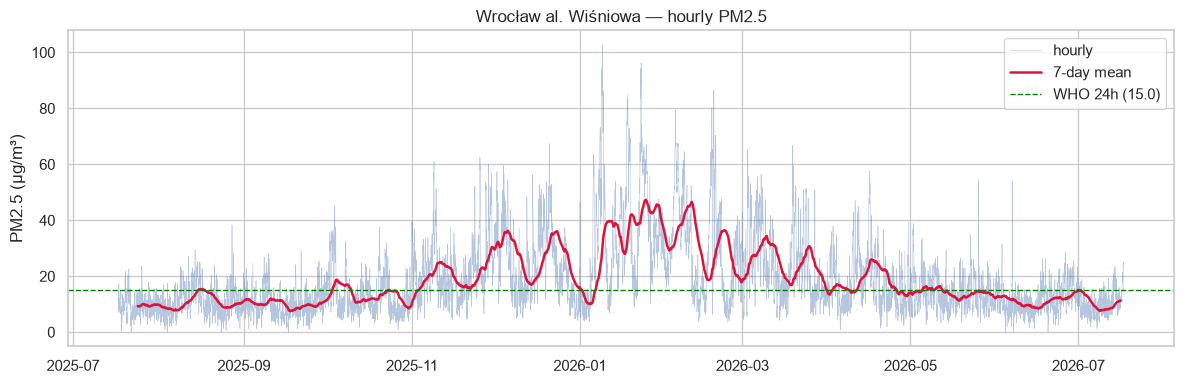

In [3]:
ts = pm25.set_index('timestamp')['value']

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(ts.index, ts.values, lw=0.4, alpha=0.4, label='hourly')
ax.plot(ts.index, ts.rolling(24 * 7).mean(), color='crimson', lw=1.8, label='7-day mean')
ax.axhline(config.PM25_WHO_DAILY, color='green', ls='--', lw=1, label=f'WHO 24h ({config.PM25_WHO_DAILY})')
ax.set(title='Wrocław al. Wiśniowa — hourly PM2.5', ylabel='PM2.5 (µg/m³)', xlabel='')
ax.legend(loc='upper right')
fig.tight_layout()
fig.savefig(config.FIGURES_DIR / 'fig1_timeseries.png', dpi=110)
plt.show()

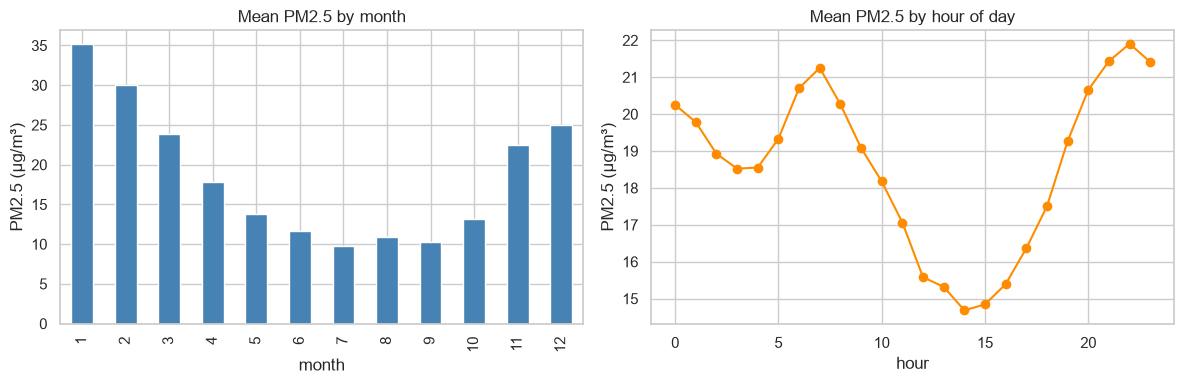

In [4]:
by_month = pm25.assign(month=pm25['timestamp'].dt.month).groupby('month')['value'].mean()
by_hour = pm25.assign(hour=pm25['timestamp'].dt.hour).groupby('hour')['value'].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
by_month.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set(title='Mean PM2.5 by month', xlabel='month', ylabel='PM2.5 (µg/m³)')
by_hour.plot(ax=axes[1], marker='o', color='darkorange')
axes[1].set(title='Mean PM2.5 by hour of day', xlabel='hour', ylabel='PM2.5 (µg/m³)')
fig.tight_layout()
fig.savefig(config.FIGURES_DIR / 'fig2_seasonality.png', dpi=110)
plt.show()

**Conclusion (Q1):** PM2.5 peaks in the cold months and in the evening/night hours —
consistent with domestic heating and a shallow boundary layer that traps pollutants.

## Q2 — How often are air-quality norms exceeded?

We compare hourly readings against the WHO 2021 24-hour guideline (15 µg/m³) and
compute the share of days whose mean exceeds it.

Days above WHO 24h guideline (15.0 µg/m³): 47.5%
Annual mean: 18.6 µg/m³ (WHO annual 5.0, EU annual 25.0)


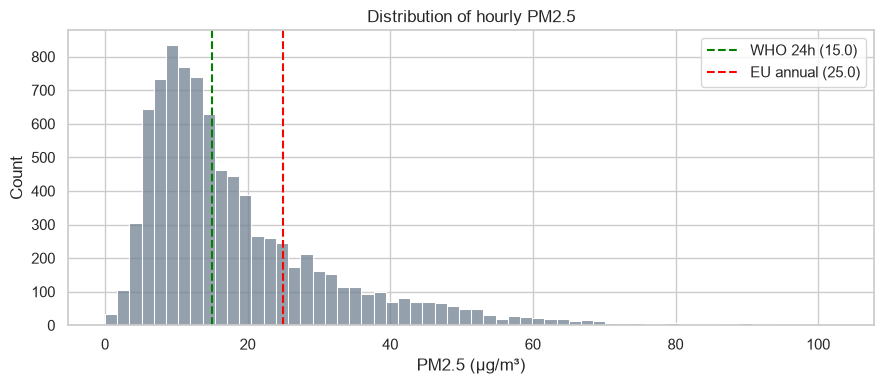

In [5]:
daily_mean = pm25.set_index('timestamp')['value'].resample('D').mean().dropna()
exceed_days = (daily_mean > config.PM25_WHO_DAILY).mean() * 100
print(f"Days above WHO 24h guideline ({config.PM25_WHO_DAILY} µg/m³): {exceed_days:.1f}%")
print(f"Annual mean: {pm25['value'].mean():.1f} µg/m³ "
      f"(WHO annual {config.PM25_WHO_ANNUAL}, EU annual {config.PM25_EU_ANNUAL})")

fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(pm25['value'].dropna(), bins=60, ax=ax, color='slategray')
ax.axvline(config.PM25_WHO_DAILY, color='green', ls='--', label=f'WHO 24h ({config.PM25_WHO_DAILY})')
ax.axvline(config.PM25_EU_ANNUAL, color='red', ls='--', label=f'EU annual ({config.PM25_EU_ANNUAL})')
ax.set(title='Distribution of hourly PM2.5', xlabel='PM2.5 (µg/m³)')
ax.legend()
fig.tight_layout()
fig.savefig(config.FIGURES_DIR / 'fig3_exceedances.png', dpi=110)
plt.show()

**Conclusion (Q2):** a substantial share of days exceed the WHO guideline, concentrated
in the heating season — the annual mean sits between the WHO and EU reference levels.

## Q3 — When is it worst? (hour × weekday)

A heatmap of mean PM2.5 by hour of day and day of week shows the temporal pockets of
high pollution.

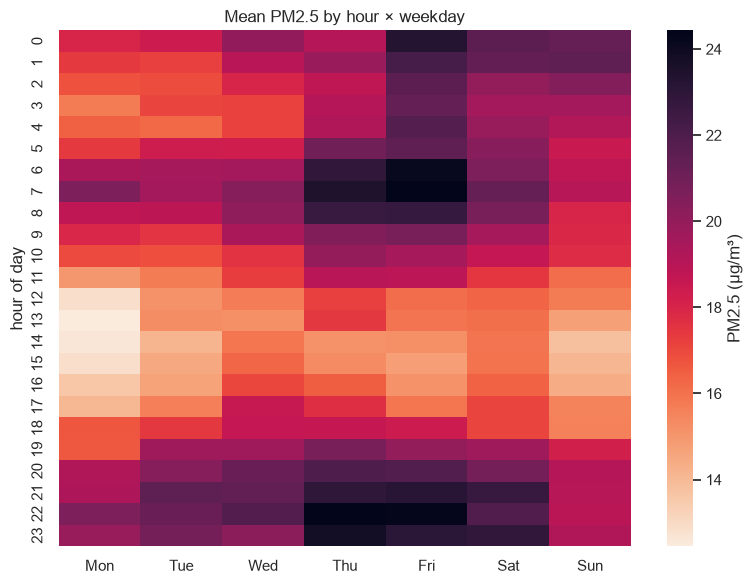

In [6]:
pivot = (pm25.assign(hour=pm25['timestamp'].dt.hour,
                     dow=pm25['timestamp'].dt.dayofweek)
              .pivot_table(index='hour', columns='dow', values='value', aggfunc='mean'))
pivot.columns = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(pivot, cmap='rocket_r', ax=ax, cbar_kws={'label': 'PM2.5 (µg/m³)'})
ax.set(title='Mean PM2.5 by hour × weekday', xlabel='', ylabel='hour of day')
fig.tight_layout()
fig.savefig(config.FIGURES_DIR / 'fig4_heatmap.png', dpi=110)
plt.show()

## Q4 — Does weather explain PM2.5?

Physically, PM2.5 falls with wind and a deep boundary layer (dispersion) and rises in
calm, stable conditions. We check correlations of PM2.5 with weather variables.

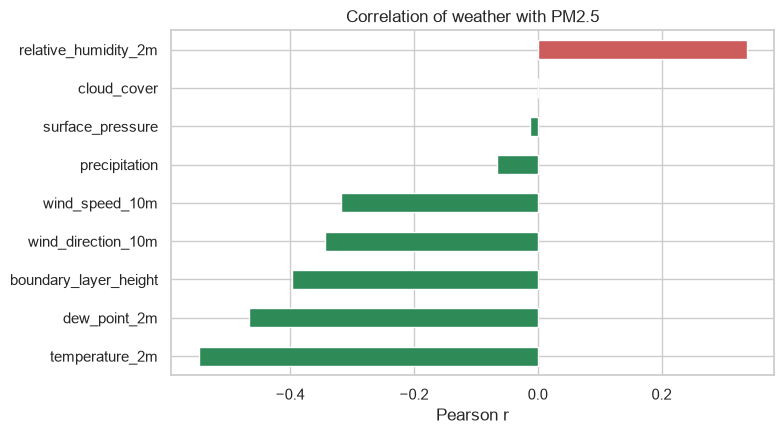

temperature_2m          -0.548
dew_point_2m            -0.466
boundary_layer_height   -0.396
wind_direction_10m      -0.344
wind_speed_10m          -0.318
precipitation           -0.065
surface_pressure        -0.013
cloud_cover              0.001
relative_humidity_2m     0.337
Name: value, dtype: float64

In [7]:
merged = pd.merge(pm25[['timestamp', 'value']], weather, on='timestamp', how='inner')
corr = merged.drop(columns='timestamp').corr()['value'].drop('value').sort_values()

fig, ax = plt.subplots(figsize=(8, 4.5))
corr.plot(kind='barh', ax=ax, color=np.where(corr < 0, 'seagreen', 'indianred'))
ax.set(title='Correlation of weather with PM2.5', xlabel='Pearson r')
fig.tight_layout()
fig.savefig(config.FIGURES_DIR / 'fig5_weather_corr.png', dpi=110)
plt.show()
corr.round(3)

**Conclusion (Q4):** wind speed and boundary-layer height correlate **negatively** with
PM2.5 (better dispersion → cleaner air), matching the physics.

## Forecast — model vs baseline

We forecast PM2.5 24 hours ahead using time + weather features (all knowable at
forecast origin — no leakage) with a **chronological** train/test split, and compare
against a persistence baseline (PM2.5 tomorrow = PM2.5 today, same hour).

In [8]:
feature_frame = features.build_features(pm25, weather)
results, rf = model.run_experiment(feature_frame)

print(f"Train rows: {results['n_train']}  |  Test rows: {results['n_test']}\n")
print(f"{'metric':<6}{'model':>10}{'baseline':>12}")
for m in ('mae', 'rmse', 'r2'):
    print(f"{m:<6}{results['model'][m]:>10}{results['baseline_persistence'][m]:>12}")
print(f"\nMAE improvement over baseline: {results['mae_improvement_pct']}%")

Train rows: 6868  |  Test rows: 1717

metric     model    baseline
mae        4.137       4.874
rmse       5.403       6.411
r2         0.026       -0.37

MAE improvement over baseline: 15.1%


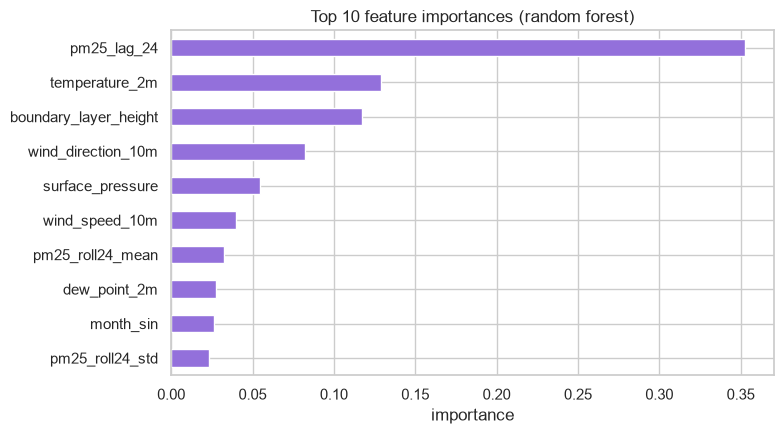

pm25_lag_24              0.353
temperature_2m           0.129
boundary_layer_height    0.117
wind_direction_10m       0.082
surface_pressure         0.055
wind_speed_10m           0.040
pm25_roll24_mean         0.032
dew_point_2m             0.028
month_sin                0.026
pm25_roll24_std          0.023
dtype: float64

In [9]:
importances = model.feature_importances(rf, features.feature_columns(feature_frame)).head(10)

fig, ax = plt.subplots(figsize=(8, 4.5))
importances.iloc[::-1].plot(kind='barh', ax=ax, color='mediumpurple')
ax.set(title='Top 10 feature importances (random forest)', xlabel='importance')
fig.tight_layout()
fig.savefig(config.FIGURES_DIR / 'fig6_importances.png', dpi=110)
plt.show()
importances.round(3)

**Conclusion (forecast):** the model beats the persistence baseline on MAE. The most
important features are recent PM2.5 (autocorrelation) together with dispersion drivers
(boundary-layer height, wind) — the model learns the physics the correlations hinted at.

### Limitations
- Single automatic station (129) — the other Wrocław stations measure PM2.5 manually
  (archive-only) or not at all, so a live multi-station comparison isn't possible here.
- History limited to ~1 year (GIOŚ archival API window) — one heating season.
- Weather features use forecast values at valid time; real forecast error at inference
  would slightly degrade live performance versus this back-test.